# JUMP-Target-2

One 384-well plate map of 302 compounds, DMSO among them, that every JUMP laboratory ran
{cite:p}`Chandrasekaran_2023`.
Differences between plates from different sources are therefore technical, which is what this dataset is for.
Twelve plates are pinned, two plates in each of two batches at three sources.

In [1]:
import mantispy as mt

adata = mt.ds.jump_target2(plates=None)
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/2OnMUz3_/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 4608 × 3634
    obs: 'Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

{func}`~mantispy.ds.jump_target2` loads two plates, one from each of two sources, unless `plates=None` asks for all
twelve.

## Source

| file | from | holds |
| --- | --- | --- |
| `<plate>.parquet` | Cell Painting Gallery, `cpg0016-jump/<source>/workspace/profiles` | the well-level profiles, with source, plate and well |
| `<plate>.csv` | Cell Painting Gallery, `cpg0016-jump/<source>/workspace/backend` | pycytominer's aggregate of the same plate, which carries the counts |
| `plate.csv.gz`, `well.csv.gz`, `compound.csv.gz` | [jump-cellpainting/datasets](https://github.com/jump-cellpainting/datasets) | what each well received |

The backend table is 35 to 56 MB per plate for two columns of it, and will be rehosted as part of this dataset's
h5ad.

## Columns mantispy adds

| column | how |
| --- | --- |
| `Metadata_Batch` | the batch directory the plate is filed under |
| `Metadata_JCP2022`, `Metadata_InChIKey` | `well.csv.gz` joined on source, plate and well, then `compound.csv.gz` |
| `Metadata_Perturbation` | `Metadata_JCP2022` |
| `Metadata_Control` | `JCP2022_033924`, DMSO |
| `Metadata_CellCount` | the backend table's `Metadata_Count_Cells`, or its `Metadata_Object_Count` where it has no other |
| `Metadata_SiteCount` | the backend table's `Metadata_Site_Count` |

source_6's backend tables publish `Metadata_Object_Count` and no `Metadata_Count_Cells`.
On plate `110000294936` it matches the count jump-profiling-recipe uses in all 384 wells.

In [2]:
obs = adata.obs
obs.groupby(["Metadata_Source", "Metadata_Batch", "Metadata_Plate"], observed=True).agg(
    wells=("Metadata_Well", "size"),
    DMSO=("Metadata_Control", "sum"),
    median_cells=("Metadata_CellCount", "median"),
)

wells  DMSO  \
Metadata_Source Metadata_Batch                 Metadata_Plate                
source_3        CP59                           JCPQC051          384    64   
                                               JCPQC052          384    64   
                CP60                           JCPQC053          384    64   
                                               JCPQC054          384    64   
source_4        2021_04_26_Batch1              BR00121438        384    64   
                                               BR00121439        384    64   
                2021_08_23_Batch12             BR00126113        384    64   
                                               BR00126114        384    64   
source_6        p210914CPU2OS48hw384exp027JUMP 110000294936      384    65   
                                               110000296682      384    64   
                p210920CPU2OS48hw384exp028JUMP 110000296339      384    64   
                                               110000296356      384    64   

                                                               median_cells  
Metadata_Source Metadata_Batch                 Metadata_Plate                
source_3        CP59                           JCPQC051              1432.5  
                                               JCPQC052              1431.5  
                CP60                           JCPQC053              1381.5  
                                               JCPQC054              1353.0  
source_4        2021_04_26_Batch1              BR00121438            1268.0  
                                               BR00121439             783.5  
                2021_08_23_Batch12             BR00126113            1403.5  
                                               BR00126114             208.0  
source_6        p210914CPU2OS48hw384exp027JUMP 110000294936          1885.5  
                                               110000296682          1860.0  
                p210920CPU2OS48hw384exp028JUMP 110000296339          2002.0  
                                               110000296356          2003.5

## Fields of view

`Metadata_Site_Count` counts the fields of view that contributed cells, not those imaged, which is nine per well.
Most wells below nine are nearly empty, but not all of them:

In [3]:
short = obs[obs["Metadata_SiteCount"] < 9]
print(
    f"{len(short)} of {adata.n_obs} wells, {int((short['Metadata_CellCount'] <= 50).sum())} of them with 50 cells or fewer"
)
columns = ["Metadata_Plate", "Metadata_Well", "Metadata_SiteCount", "Metadata_CellCount"]
short.sort_values("Metadata_CellCount", ascending=False)[columns].head(6)

90 of 4608 wells, 78 of them with 50 cells or fewer


,Metadata_Plate,Metadata_Well,Metadata_SiteCount,Metadata_CellCount
4423,110000296356,I08,8.0,1825.0
3996,110000296339,G13,8.0,1709.0
3344,110000294936,L09,8.0,193.0
3064,BR00126114,P17,8.0,175.0
2938,BR00126114,K11,8.0,147.0
2759,BR00126114,C24,8.0,137.0


Two wells with over 1,700 cells each lost a field outright.
On BR00126114, the sparsest plate, a well can hold 130 to 175 cells and still leave a field empty.
Either way, the count covers eight fields where the plate's other wells cover nine, which is why
{func}`~mantispy.tl.cytotoxicity` compares cells per field.

## What it looks like

The sources seed different numbers of cells, and source_4's plates differ as much among themselves: BR00126114
holds a median of 208 cells a well against 1,404 on BR00126113.
Within a plate, the strongest compounds are cytotoxic.

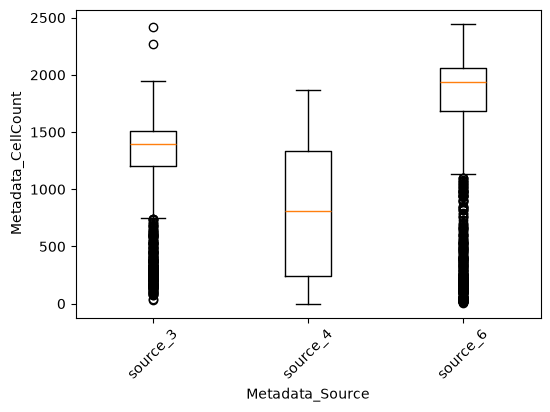

In [4]:
ax = mt.pl.cell_counts(adata, groupby="Metadata_Source")

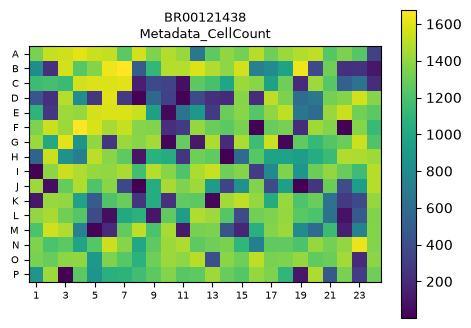

In [5]:
ax = mt.pl.plate(adata, color="Metadata_CellCount", plate="BR00121438")

Wells with a fraction of the plate's cells are why a distance from the controls alone ranks cell death as the
strongest phenotype on this plate; {func}`~mantispy.tl.cytotoxicity` flags them.